# Hough Transform

## 2D median filter

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


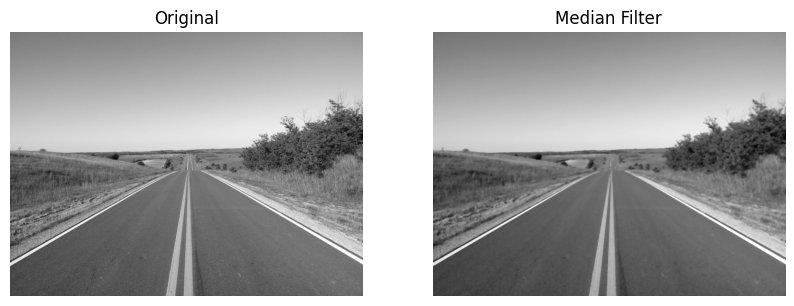

In [ ]:
laneimg = cv2.imread("lane.jpg", 0)   

filteredLaneImage = cv2.medianBlur(laneimg, 5)  

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(laneimg, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filteredLaneImage, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

plt.show()


## Canny Edge Detection

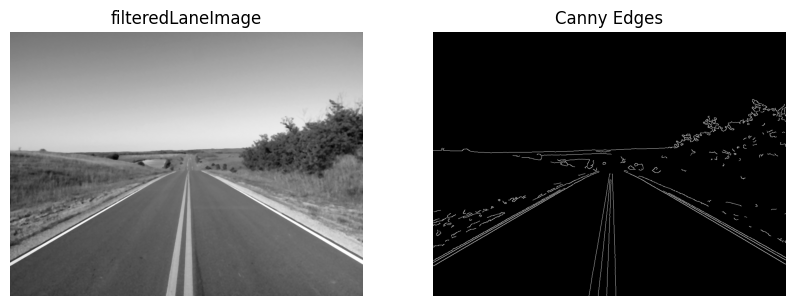

In [5]:
edges = cv2.Canny(filteredLaneImage, 100, 200)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(filteredLaneImage, cmap='gray')
plt.title("filteredLaneImage")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

plt.show()


## ROI

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

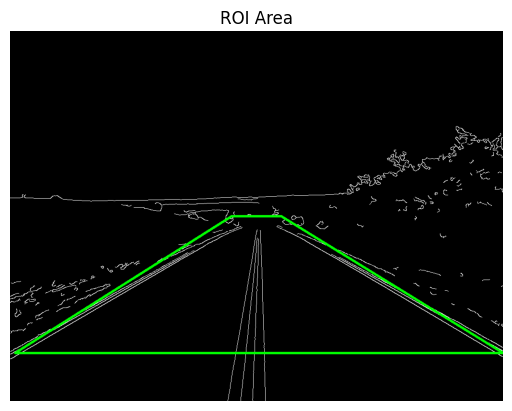

In [58]:
img_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

height, width = edges.shape

polygon = np.array([
    (int(width*0.01), int(height*0.87)),
    (int(width*0.45), int(height*0.5)),
    (int(width*0.55), int(height*0.5)),
    (int(width), int(height*0.87))
])

cv2.polylines(img_color, [polygon], True, (0,255,0), 3)

plt.imshow(img_color)
plt.title("ROI Area")
plt.axis("off")

In [ ]:
def region_of_interest(img):
    height = img.shape[0]
    width = img.shape[1]

    # Creates a trapezoidal region
    polygon = np.array([[
        (int(width*0.01), int(height*0.85)),
        (int(width*0.45), int(height*0.5)),
        (int(width*0.55), int(height*0.5)),
        (int(width), int(height*0.85))
    ]], dtype=np.int32)  
    # Create mask
    mask = np.zeros_like(img)

    # Fill polygon
    cv2.fillPoly(mask, polygon, 255)

    # Apply mask
    masked_image = cv2.bitwise_and(img, mask)

    return masked_image


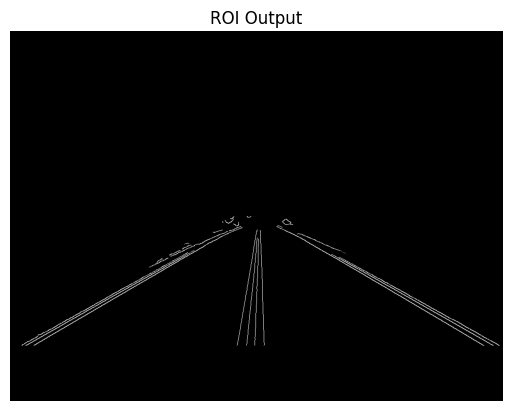

In [57]:
roi_edges = region_of_interest(edges)
plt.imshow(roi_edges, cmap='gray')
plt.title("ROI Output")
plt.axis("off")
plt.show()
